In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data_path = "/content/USA_Housing.csv"
df = pd.read_csv(data_path)

In [ ]:
X = np.column_stack([
    df['Avg. Area Income'],
    df['Avg. Area House Age'],
    df['Avg. Area Number of Rooms'],
    df['Avg. Area Number of Bedrooms'],
    df['Area Population']
])

y = df['Price']

In [ ]:
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (5000, 5)
y shape: (5000,)


KNN **Regression**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {len(X_train)} samples")
print(f"Test: {len(X_test)} samples")

Train: 4000 samples
Test: 1000 samples


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

knn_no_scale = KNeighborsRegressor(n_neighbors=5)
knn_no_scale.fit(X_train, y_train)
y_pred_no_scale = knn_no_scale.predict(X_test)

print("WITHOUT Scaling:")
print(f"R² = {r2_score(y_test, y_pred_no_scale):.3f}")

WITHOUT Scaling:
R² = 0.485


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=5))
])

pipeline.fit(X_train, y_train)
y_pred_scaled = pipeline.predict(X_test)

print("WITH Scaling (Pipeline):")
print(f"R² = {r2_score(y_test, y_pred_scaled):.3f}")

WITH Scaling (Pipeline):
R² = 0.869


**Choosing K**

In [ ]:
import matplotlib.pyplot as plt

k_values = range(1, 31)
train_errors = []
test_errors = []

for k in k_values:
    pipeline_k = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor(n_neighbors=k))
    ])
    pipeline_k.fit(X_train, y_train)

    train_errors.append(mean_squared_error(y_train, pipeline_k.predict(X_train)))
    test_errors.append(mean_squared_error(y_test, pipeline_k.predict(X_test)))

In [ ]:
best_k = k_values[np.argmin(test_errors)]
print(f"Best K: {best_k}")
print(f"Best Test MSE: ${min(test_errors):,.0f}")

Best K: 9
Best Test MSE: $15,311,227,372


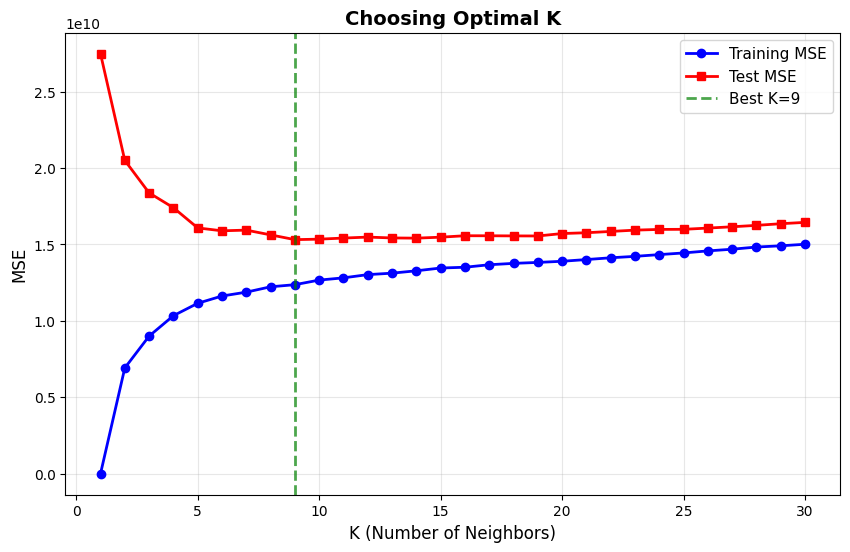

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_errors, 'bo-', label='Training MSE', linewidth=2, markersize=6)
plt.plot(k_values, test_errors, 'rs-', label='Test MSE', linewidth=2, markersize=6)
plt.axvline(best_k, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Best K={best_k}')
plt.xlabel('K (Number of Neighbors)', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('Choosing Optimal K', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

**Save and Load Model**

In [ ]:
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=best_k))
])

final_pipeline.fit(X_train, y_train)

print(f"Trained final model with K={best_k}")
print(f"Test R²: {r2_score(y_test, final_pipeline.predict(X_test)):.3f}")

Trained final model with K=9
Test R²: 0.876


In [ ]:
import joblib

joblib.dump(final_pipeline, 'house_price_knn.pkl')

['house_price_knn.pkl']

In [ ]:
loaded_pipeline = joblib.load('house_price_knn.pkl')

In [ ]:
test_house = [[1500, 6, 3, 4, 6]]  # 1500 sqft, 3 bedrooms
prediction = loaded_pipeline.predict(test_house)[0]

print(f"Predicted Price: ${prediction:,.0f}")

Predicted Price: $525,669
